## **Import Libraries & Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_RAW = Path("../data/raw")
print("Ready!")

Ready!


## **Load All Tables**

Load all 8 Olist CSV tables into separate DataFrames.
 
The Olist dataset follows a relational structure similar to an ERD:
- `orders` → core transaction table
- `order_items` → line items per order
- `payments` → payment method and value per order
- `products` + `category` → product info with English category name translation
- `customers` + `sellers` → buyer and seller profiles
- `reviews` → customer review scores and comments

In [2]:
orders       = pd.read_csv(DATA_RAW / "olist_orders_dataset.csv")
order_items  = pd.read_csv(DATA_RAW / "olist_order_items_dataset.csv")
payments     = pd.read_csv(DATA_RAW / "olist_order_payments_dataset.csv")
products     = pd.read_csv(DATA_RAW / "olist_products_dataset.csv")
customers    = pd.read_csv(DATA_RAW / "olist_customers_dataset.csv")
sellers      = pd.read_csv(DATA_RAW / "olist_sellers_dataset.csv")
reviews      = pd.read_csv(DATA_RAW / "olist_order_reviews_dataset.csv")
category     = pd.read_csv(DATA_RAW / "product_category_name_translation.csv")

tables = {
    "orders": orders, "order_items": order_items, "payments": payments,
    "products": products, "customers": customers, "sellers": sellers,
    "reviews": reviews, "category": category,
}

for name, df in tables.items():
    print(f"{name:15s} → {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols")

orders          →  99,441 rows ×  8 cols
order_items     → 112,650 rows ×  7 cols
payments        → 103,886 rows ×  5 cols
products        →  32,951 rows ×  9 cols
customers       →  99,441 rows ×  5 cols
sellers         →   3,095 rows ×  4 cols
reviews         →  99,224 rows ×  7 cols
category        →      71 rows ×  2 cols


## **Tables Preview**

In [17]:
display(orders.head(3))
display(order_items.head(3))
display(payments.head(3))
display(products.head(3))
display(customers.head(3))
display(sellers.head(3))
display(reviews.head(3))
display(category.head(3))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## **Orders: date range + status distribution**

Understand the temporal coverage of the dataset and the distribution of order statuses.
 
**Why this matters:**
- The date range determines how far back we can look for trend analysis and baselines
- Order status distribution shows what proportion of transactions are fully completed
  (`delivered`) vs. canceled, in-transit, etc. — only `delivered` orders will be
  used for revenue analysis to ensure accuracy
 
**Expected result:** the vast majority of orders should have status `delivered`.

In [3]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

print("=== Date Range ===")
print(f"From : {orders['order_purchase_timestamp'].min().date()}")
print(f"To   : {orders['order_purchase_timestamp'].max().date()}")

print("\n=== Order Status ===")
print(orders["order_status"].value_counts())

=== Date Range ===
From : 2016-09-04
To   : 2018-10-17

=== Order Status ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## **Revenue overview (delivered orders only)**

Compute basic revenue statistics scoped to fully delivered orders only.
 
**Why filter to `delivered` only?**
Orders that are canceled, in processing, or in transit have not generated realized revenue.
Including them would inflate or distort our KPI figures.
 
**Metrics computed:**
- Total orders & total revenue → overall scale of the business
- Average Order Value (AOV) → a key metric we will monitor for anomalies
- Median → more robust than mean in the presence of high-value outliers
- Max → helps identify potential outliers worth investigating

In [6]:
delivered = orders[orders["order_status"] == "delivered"]["order_id"]
pay_delivered = payments[payments["order_id"].isin(delivered)]
pay_agg = pay_delivered.groupby("order_id")["payment_value"].sum()

print("=== Revenue Summary (delivered orders) ===")
print(f"Total orders  : {len(pay_agg):,}")
print(f"Total revenue : R$ {pay_agg.sum():,.2f}")
print(f"Avg per order : R$ {pay_agg.mean():,.2f}")
print(f"Median        : R$ {pay_agg.median():,.2f}")
print(f"Max           : R$ {pay_agg.max():,.2f}")

=== Revenue Summary (delivered orders) ===
Total orders  : 96,477
Total revenue : R$ 15,422,461.77
Avg per order : R$ 159.86
Median        : R$ 105.28
Max           : R$ 13,664.08


## **Monthly revenue trend**

Visualize the monthly revenue trend across the full dataset period (2016–2018).
 
**Why this matters for our system:**
This trend becomes the historical **baseline** used by the anomaly detector.
The system needs to understand seasonal patterns and growth trajectories to
distinguish genuine anomalies from expected fluctuations.
 
**Key questions to observe:**
- Is there a consistent seasonal pattern across years?
- Are there months with sharp spikes or drops?
- Is the overall trend growing, declining, or flat?

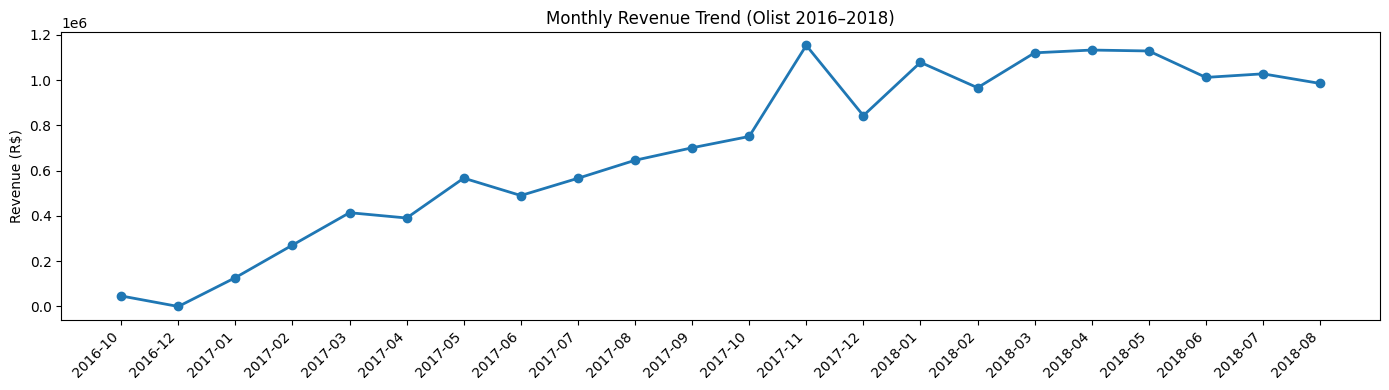


Peak month  : 2017-11
Lowest month: 2016-12


In [15]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

monthly = (
    orders[orders["order_status"] == "delivered"]
    .merge(payments.groupby("order_id")["payment_value"].sum().reset_index(), on="order_id")
    .groupby("month")["payment_value"].sum()
    .reset_index()
)
monthly["month_str"] = monthly["month"].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(monthly["month_str"], monthly["payment_value"], marker="o", linewidth=2)
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Revenue Trend (Olist 2016–2018)")
plt.ylabel("Revenue (R$)")
plt.tight_layout()
plt.show()

print(f"\nPeak month  : {monthly.loc[monthly['payment_value'].idxmax(), 'month_str']}")
print(f"Lowest month: {monthly.loc[monthly['payment_value'].idxmin(), 'month_str']}")

## **Revenue by product category (top 15)**

Break down revenue by product category — one of the primary dimensions for anomaly detection.
 
**Why the category dimension matters:**
Anomalies often occur at the category level while the overall total appears normal.
For example: total revenue looks fine, but the `electronics` category has quietly dropped 30%.
Our system must be able to surface these hidden signals.
 
**Join chain performed:**
`order_items` → `products` → `category` (English name translation) → `payments` (revenue value)
 
The top 15 categories identified here will serve as priority dimensions in the KPI engine.

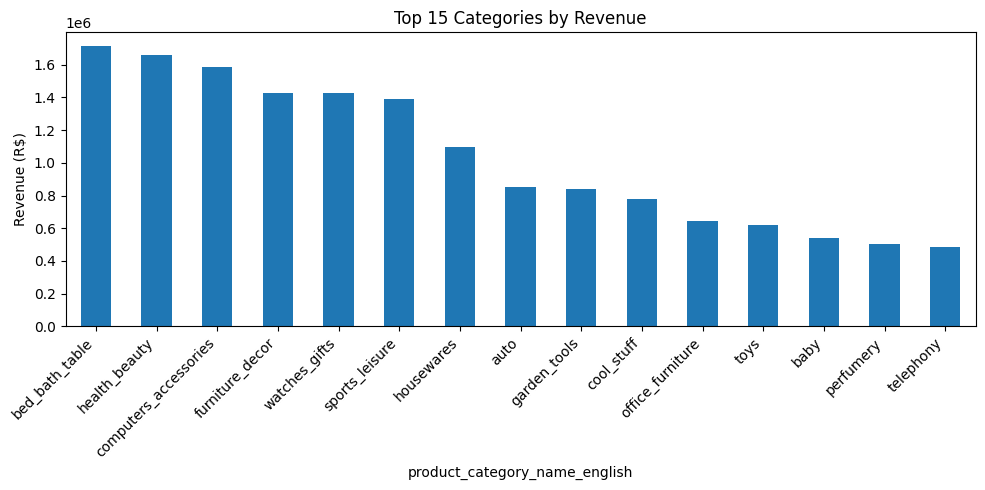

In [18]:
items_with_cat = (
    order_items
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category, on="product_category_name", how="left")
    .merge(payments.groupby("order_id")["payment_value"].sum().reset_index(), on="order_id", how="left")
)

cat_revenue = (
    items_with_cat
    .groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
cat_revenue.plot(kind="bar")
plt.title("Top 15 Categories by Revenue")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## **Revenue by customer state (top 10)**

Break down revenue by customer location (Brazilian state).
 
**Why the geographic dimension matters:**
Revenue drops localized to a single region often point to specific root causes:
logistics disruptions, local seller issues, or regional economic conditions.
Monitoring at the state level allows the system to deliver more precise diagnoses.
 
**Expected result:** SP (São Paulo) and RJ (Rio de Janeiro) should dominate,
as they are Brazil's largest economic centers — these will serve as our geographic baseline.

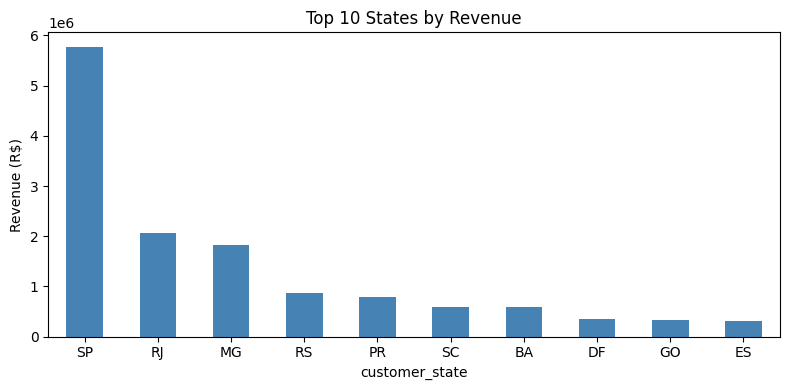

In [19]:
state_revenue = (
    orders[orders["order_status"] == "delivered"]
    .merge(customers[["customer_id", "customer_state"]], on="customer_id")
    .merge(payments.groupby("order_id")["payment_value"].sum().reset_index(), on="order_id")
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
state_revenue.plot(kind="bar", color="steelblue")
plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Null check on key columns**

Check for missing values (null/NaN) in the critical columns we will rely on downstream.
 
**Why check this now?**
Null values in key columns like `order_id`, `payment_value`, or `order_status` can
silently corrupt KPI calculations or cause runtime errors mid-pipeline.
Identifying data quality issues at the EDA stage is far cheaper than debugging later.
 
**Columns checked:**
- `orders` → transaction identity and timestamps
- `order_items` → product details and pricing
- `payments` → revenue values that will be aggregated per order

In [20]:
print("=== Null Check: orders ===")
print(orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]].isnull().sum())

print("\n=== Null Check: order_items ===")
print(order_items[["order_id", "product_id", "price", "freight_value"]].isnull().sum())

print("\n=== Null Check: payments ===")
print(payments[["order_id", "payment_value"]].isnull().sum())

=== Null Check: orders ===
order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
dtype: int64

=== Null Check: order_items ===
order_id         0
product_id       0
price            0
freight_value    0
dtype: int64

=== Null Check: payments ===
order_id         0
payment_value    0
dtype: int64


## **Summary: what we'll use for KPI engine**

In [22]:
print("""
=== TABLES WE'LL USE ===

orders          → order_id, customer_id, order_status, order_purchase_timestamp
order_items     → order_id, product_id, price, freight_value
payments        → order_id, payment_value  (aggregated per order)
products        → product_id, product_category_name
customers       → customer_id, customer_state
category        → product_category_name → product_category_name_english

=== KEY DIMENSIONS FOR ANOMALY DETECTION ===
- Time       : daily / weekly / monthly
- Category   : product_category_name_english
- Geography  : customer_state
- Volume     : order count
- Value      : payment_value (revenue)
- AOV        : revenue / order_count
""")


=== TABLES WE'LL USE ===

orders          → order_id, customer_id, order_status, order_purchase_timestamp
order_items     → order_id, product_id, price, freight_value
payments        → order_id, payment_value  (aggregated per order)
products        → product_id, product_category_name
customers       → customer_id, customer_state
category        → product_category_name → product_category_name_english

=== KEY DIMENSIONS FOR ANOMALY DETECTION ===
- Time       : daily / weekly / monthly
- Category   : product_category_name_english
- Geography  : customer_state
- Volume     : order count
- Value      : payment_value (revenue)
- AOV        : revenue / order_count

